In [1]:
import typing as T
import pickle
import json
import os
import pathlib
import pathlib as P
import sys
import pandas as pd
import itertools as it
import functools as ft
import operator as opr
import collections as clt
import math
from math import pi

In [2]:
prj_root = P.Path("__file__").absolute().parent.parent.parent
if (p := str(prj_root)) not in sys.path:
  sys.path.append(p)

In [3]:
import util.metrics as um
import sklearn.metrics as metrics

In [4]:
import numpy as np
import scipy.sparse as sp
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats as ss
import seaborn as sns
from tqdm import tqdm

In [5]:
ns = ['cc', 'mf', 'bp']
ontology_lst = ["cellular_component",
                "molecular_function",
                "biological_process"]

In [6]:
data_path = [f"/data0/shaojiangyi/pprogo-flg-1/data/data-netgo/{x}_data.pkl"
             for x in ["train", "valid", "test"]]
prot_data = pd.concat([pd.read_pickle(x) for x in data_path], ignore_index=True)

In [7]:
prot_test_data = pd.read_pickle(data_path[-1])

In [8]:
prot_test_lst = prot_test_data["proteins"].to_list()

In [9]:
prot_test_set = set(prot_test_lst)

In [10]:
prot_labels = []
for n in ns:
    y_label = prj_root / "data" / n / "label.pkl"
    with open(y_label, "rb") as f:
        labels = pickle.load(f)
    tmp = clt.defaultdict(list)
    for k, v in zip(labels["protein"], labels["go"]):
        tmp[k].append(v)
    prot_labels.append(tmp)

In [11]:
label_dir = P.Path("/data0/zhaojianxiang/data/")
curr_labels = []
for n in ns:
    label_path = label_dir / n / "go_list.txt"
    with open(label_path, "r") as f:
        labels = f.read().splitlines()
    curr_labels.append(labels)
namespace_terms = dict(zip(ontology_lst, curr_labels))

In [12]:
nspace_ti = {k: {x: i for i, x in enumerate(v)}
             for k, v in namespace_terms.items()}

In [13]:
ti_lst = list(nspace_ti.values())

In [14]:
# get protein name id
name_path = prj_root / "data" / "protein_name.txt"
with open(name_path, "r") as f:
    prot_lst = f.read().splitlines()# load prot names

In [15]:
# convert protein idx and label idx to protein name and go term respectively
for i, n in enumerate(ontology_lst):
    prot_labels[i] = {
        prot_lst[k]: [namespace_terms[n][x] for x in v]
        for k, v in prot_labels[i].items()
    }


In [16]:
prot_test_labels = [{p: x for p, x in d.items() if p in prot_test_set}
                    for d in prot_labels]

In [17]:
ptesti_lst = [{p: i for i, p in enumerate(d.keys())}
               for d in prot_test_labels]

In [18]:
ci_path = "/data0/shaojiangyi/pprogo-flg-1/data/data-netgo/term_counts_with_position-111.pkl"
term_count_ic = pd.read_pickle(ci_path)

In [19]:
label_dir = P.Path("/data0/zhaojianxiang/data/")
curr_labels = []
for n in ns:
    label_path = label_dir / n / "go_list.txt"
    with open(label_path, "r") as f:
        labels = f.read().splitlines()
    curr_labels.append(labels)

namespace_terms = dict(zip(ontology_lst, curr_labels))

In [20]:
#%%

# load protein ic
msq_pth = P.Path("/data0/shaojiangyi/pprogo-flg-1/data/mmseq_sim_csr.npz")
msq_mat = sp.load_npz(msq_pth)

In [21]:
# %%

# calculate the degree of each protein 
# the msq_mat is a sparse matrix where the score denote the mmseqs identity score
# when calculating the degree, all the scores are considered as 1

# copy a matrix where the scores are all 1
msq_mat_deg = msq_mat.copy()
msq_mat_deg.data = np.ones_like(msq_mat_deg.data)
# calculate the indegree of each protein
prot_deg = msq_mat_deg.sum(axis=0).A1

# create a dataframe with the protein names and their degrees
prot_deg_df = pd.DataFrame({
    "proteins": prot_lst,
    "indegree": prot_deg
}).astype({"proteins": str, "indegree": int})

In [22]:
# %%

# calculate the IC (information content) based on the degree
# first get all the number of triangular edges in the matrix
num_prots = len(prot_lst)
prot_deg_df["ic"] = np.log2(num_prots / prot_deg_df["indegree"])

In [23]:
np.linspace(0, 1, 20, endpoint=False)

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95])

In [24]:
# %%

np.quantile(prot_deg_df["ic"], np.linspace(0, 1, 20, endpoint=False))

array([4.33704172, 7.26977798, 7.56327767, 7.73100511, 7.86013374,
       7.96954496, 8.06596129, 8.14275254, 8.21347054, 8.27697348,
       8.33211504, 8.3855543 , 8.4370139 , 8.49456492, 8.55014227,
       8.61704893, 8.71625853, 8.87098112, 9.21347054, 9.93214499])

In [25]:
np.quantile(term_count_ic["ic"], np.linspace(0, 1, 20, endpoint=False))

array([ 0.        ,  7.4657283 ,  8.89190698,  9.84925898, 10.54334375,
       11.12303311, 11.62260412, 12.08826769, 12.51262825, 12.89562261,
       13.31066011, 13.65013177, 13.97205986, 14.38709736, 14.75593074,
       14.97205986, 15.48058511, 15.97205986, 16.34089324, 16.48058511])

In [26]:
method_names = [
  "ProGO-PFL",
  # "DeepGOPlus",
#   "TALE",
  # "DeepFRI",
  "Non-Weak Association",
  # "PFresGO",
]
method_predictions = clt.defaultdict(list)


In [27]:
# load method

for ont in ns:
  # N = 5
  # tmp_lst = []
  # for i in range(N):
  #   pred_path = f"/data0/shaojiangyi/pprogo-flg-1/results/HGAT_{ont}_{i}.npz"
  #   tmp = np.load(pred_path)
  #   pred = np.stack((tmp["labels"], tmp["preds"]), axis=0)
  #   tmp_lst.append(pred)
  pred_path = f"/data0/shaojiangyi/pprogo-flg-1/results/HGAT_{ont}_best.npz"
  tmp = np.load(pred_path)
  pred = np.stack((tmp["labels"], tmp["preds"]), axis=0)
  # tmp_lst.append(pred)
  # # average the predictions
  # pred = np.stack((tmp_lst[0][0], np.mean([x[1] for x in tmp_lst], axis=0)), axis=0)
  # pred_path = f"/data0/shaojiangyi/pprogo-flg-1/results/HGAT_{ont}_2.npz"
  # tmp = np.load(pred_path)
  # pred = np.stack((tmp["labels"], tmp["preds"]), axis=0)
  method_predictions["ProGO-PFL"].append(pred)

In [28]:
root_paths = [
    # "/data0/shaojiangyi/pprogo-flg-1/netgo_benchmark/netgo-deepgoplus/data-netgo",
    # "/data0/shaojiangyi/pprogo-flg-1/netgo_benchmark/netgo-tale/data-netgo",
    # "/data0/shaojiangyi/pprogo-flg-1/netgo_benchmark/netgo-deepfri/data-netgo",
    "/data0/shaojiangyi/pprogo-flg-1/netgo_benchmark/netgo-gcn",
    # "/data0/shaojiangyi/pprogo-flg-1/netgo_benchmark/netgo-pfresgo/data-netgo",
]

In [29]:
for label_dir, method_name in zip(root_paths,
                                  method_names[1:]):
  pred_paths = [P.Path(label_dir) / f"{ns[i]}_result_aligned.npy" for i in range(len(ns))]
  for i, pred_path in enumerate(pred_paths):
    if not pred_path.exists():
      print(f"File {pred_path} does not exist.")
      continue
    preds = np.load(pred_path)
    if preds.ndim == 1:
      preds = preds[:, None]
    # pring shape
    print(f"Method: {method_name}, Namespace: {ns[i]}, Shape: {preds.shape}")
    method_predictions[method_name].append(preds)

Method: Non-Weak Association, Namespace: cc, Shape: (2, 268, 2852)
Method: Non-Weak Association, Namespace: mf, Shape: (2, 505, 6786)
Method: Non-Weak Association, Namespace: bp, Shape: (2, 491, 21677)


In [30]:
get_fmax = ft.partial(
                      um.fmax_score, 
                            # need_threshold=True, 
                            # curve=True
                            auprc=True,
                            no_empty_labels=True,
                            no_zero_classes=True,
                            drop_intermediate=True,
                            )

In [31]:
prot_ic_ths = [None] + np.quantile(prot_deg_df["ic"], [0.25, 0.5]).round(2).tolist() + [None]
go_ic_ths = [None] + np.quantile(term_count_ic["ic"], [0.25, 0.5]).round(2).tolist() + [None]

In [32]:
protic_range = [(prot_ic_ths[i], prot_ic_ths[i+1])
            for i in range(len(prot_ic_ths)-1)]
goic_range = [(go_ic_ths[i], go_ic_ths[i+1])
              for i in range(len(go_ic_ths)-1)]

In [33]:
protic_range

[(None, 7.97), (7.97, 8.33), (8.33, None)]

In [34]:
goic_range

[(None, 11.12), (11.12, 13.31), (13.31, None)]

In [35]:
icrp = list(it.product(protic_range, goic_range))

In [36]:
icrp

[((None, 7.97), (None, 11.12)),
 ((None, 7.97), (11.12, 13.31)),
 ((None, 7.97), (13.31, None)),
 ((7.97, 8.33), (None, 11.12)),
 ((7.97, 8.33), (11.12, 13.31)),
 ((7.97, 8.33), (13.31, None)),
 ((8.33, None), (None, 11.12)),
 ((8.33, None), (11.12, 13.31)),
 ((8.33, None), (13.31, None))]

In [37]:
# remove some range


In [38]:
def get_range_labelname(low, high):
    if low is None:
        return f"(-inf, {high})"
    elif high is None:
        return f"[{low}, +inf)"
    else:
        return f"[{low}, {high})" 

In [39]:
def fmax_range(
               targs: np.ndarray, 
               preds: np.ndarray,
               godict_lst: T.List[T.Dict[str, int]],
               term_ic: pd.DataFrame,
               protdict_lst: T.List[T.Dict[str, int]],
               protein_ic: pd.DataFrame,
               by: int, # cc, mf, bp are 0, 1, 2
               prot_ic_range: T.Tuple = None, # select proteins
               go_ic_range: T.Tuple = None, # select gos
               ):
  if prot_ic_range is None and go_ic_range is None:
    return get_fmax(targs, preds)
  
  go_dict = godict_lst[by]
  prot_dict = protdict_lst[by]
  
  min_pic, max_pic = math.trunc(protein_ic["ic"].min()), protein_ic["ic"].max()
  min_gic, max_gic = math.trunc(term_ic["ic"].min()), term_ic["ic"].max()

  r1, r2 = prot_ic_range
  c1, c2 = go_ic_range

  if r1 is None: r1 = min_pic
  if r2 is None: r2 = max_pic
  if c1 is None: c1 = min_gic
  if c2 is None: c2 = max_gic

  r_indeices = protein_ic[(protein_ic["ic"] >= r1) &
                          (protein_ic["ic"] < r2)]["proteins"]\
                            .transform(lambda x: prot_dict.get(x, pd.NA))\
                            .dropna().to_numpy(dtype=int)
  c_indices = term_ic[(term_ic["ic"] >= c1) &
                      (term_ic["ic"] < c2)]["gos"]\
                      .transform(lambda x: go_dict.get(x, pd.NA))\
                      .dropna().to_numpy(dtype=int)
  
  if len(r_indeices) <= 0 or len(c_indices) <= 0:
    return None, None
  else:
    sub_targs = targs[np.ix_(r_indeices, c_indices)]
    sub_preds = preds[np.ix_(r_indeices, c_indices)]
    if sub_targs.sum() <= 0: 
      return None, None
    else:
      return get_fmax(sub_targs, sub_preds)

In [40]:
call_fx = [ft.partial(fmax_range, godict_lst=ti_lst, term_ic=term_count_ic,
                      protdict_lst=ptesti_lst, protein_ic=prot_deg_df,
                      prot_ic_range=r, go_ic_range=c,
                      )
           for r, c in icrp]

In [41]:
perf_data = clt.defaultdict(list)
for i in range(len(ns)):
    for j, m in method_predictions.items():
        for k, func in tqdm(enumerate(call_fx),ncols=120):
            perf_data["ontology"].append(ontology_lst[i])
            perf_data["method"].append(j)
            pred_ary = m[i]
            fvalue, avalue = func(targs=pred_ary[0], preds=pred_ary[1], by=i)
            perf_data["fmax"].append(fvalue)
            perf_data["auprc"].append(avalue)
            perf_data["protein_ic"].append(get_range_labelname(*icrp[k][0]))
            perf_data["go_ic"].append(get_range_labelname(*icrp[k][1]))

9it [00:00, 54.23it/s]
9it [00:00, 57.23it/s]
9it [00:00, 48.36it/s]
9it [00:00, 47.96it/s]
9it [00:00, 30.13it/s]
9it [00:00, 29.32it/s]


In [42]:
perf_df = pd.DataFrame(perf_data)

In [43]:
perf_df

,ontology,method,fmax,auprc,protein_ic,go_ic
0,cellular_component,ProGO-PFL,0.601463,0.660568,"(-inf, 7.97)","(-inf, 11.12)"
1,cellular_component,ProGO-PFL,0.727273,0.726894,"(-inf, 7.97)","[11.12, 13.31)"
2,cellular_component,ProGO-PFL,0.800000,0.793651,"(-inf, 7.97)","[13.31, +inf)"
3,cellular_component,ProGO-PFL,0.640625,0.700213,"[7.97, 8.33)","(-inf, 11.12)"
4,cellular_component,ProGO-PFL,0.684211,0.656414,"[7.97, 8.33)","[11.12, 13.31)"
5,cellular_component,ProGO-PFL,0.631579,0.386213,"[7.97, 8.33)","[13.31, +inf)"
6,cellular_component,ProGO-PFL,0.634281,0.662126,"[8.33, +inf)","(-inf, 11.12)"
7,cellular_component,ProGO-PFL,0.577778,0.483737,"[8.33, +inf)","[11.12, 13.31)"
8,cellular_component,ProGO-PFL,0.727273,0.697295,"[8.33, +inf)","[13.31, +inf)"
9,cellular_component,Non-Weak Association,0.519504,0.542958,"(-inf, 7.97)","(-inf, 11.12)"


In [44]:
perf_df[perf_df["method"]=="ProGO-PFL"]

,ontology,method,fmax,auprc,protein_ic,go_ic
0,cellular_component,ProGO-PFL,0.601463,0.660568,"(-inf, 7.97)","(-inf, 11.12)"
1,cellular_component,ProGO-PFL,0.727273,0.726894,"(-inf, 7.97)","[11.12, 13.31)"
2,cellular_component,ProGO-PFL,0.800000,0.793651,"(-inf, 7.97)","[13.31, +inf)"
3,cellular_component,ProGO-PFL,0.640625,0.700213,"[7.97, 8.33)","(-inf, 11.12)"
4,cellular_component,ProGO-PFL,0.684211,0.656414,"[7.97, 8.33)","[11.12, 13.31)"
5,cellular_component,ProGO-PFL,0.631579,0.386213,"[7.97, 8.33)","[13.31, +inf)"
6,cellular_component,ProGO-PFL,0.634281,0.662126,"[8.33, +inf)","(-inf, 11.12)"
7,cellular_component,ProGO-PFL,0.577778,0.483737,"[8.33, +inf)","[11.12, 13.31)"
8,cellular_component,ProGO-PFL,0.727273,0.697295,"[8.33, +inf)","[13.31, +inf)"
18,molecular_function,ProGO-PFL,0.728361,0.735069,"(-inf, 7.97)","(-inf, 11.12)"


In [65]:
clst = [
    "#c75c64",
    "#6270b6", 
    "#4c8bc0",
    "#97CDC4",
    "#7E9A38",
    "#E5DF8B",
    "#F0B57D",
]

In [77]:
def create_radar_plots(df,save_path=None):
    # Filter out rows where both fmax and auprc are NaN or None
    df_filtered = df.dropna(subset=['fmax', 'auprc'], how='all')
    
    # Get unique values
    ontologies = df_filtered['ontology'].unique()
    methods = df_filtered['method'].unique()
    metrics = ['fmax', 'auprc']
    
    # Create a figure with 2 rows and 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(projection='polar'))
    # fig.suptitle('Performance Comparison Across Methods and Ontologies', fontsize=16, y=0.95)
    
    # Color palette for different methods
    bias = 1
    n_methods = len(methods)
    colors = plt.cm.magma(np.linspace(0, 1, n_methods+bias)[:n_methods][::-1])
    # assert n_methods <= len(clst)
    # colors = clst[:n_methods]
    # colors = plt.colormaps.get("myset1")(np.linspace(0, 1, len(methods)))
    method_colors = dict(zip(methods, colors))
    
    for row, metric in enumerate(metrics):
        for col, ontology in enumerate(ontologies):
            ax = axes[row, col]
            
            # Filter data for current metric and ontology
            current_data = df_filtered[df_filtered['ontology'] == ontology]
            
            if current_data.empty:
                ax.set_title(f'{metric.upper()} - {ontology.replace("_", " ").title()}')
                continue
            
            # Group by method and calculate mean values for each protein_ic and go_ic combination
            # Create categories based on protein_ic and go_ic for radar axes
            current_data = current_data.copy()
            current_data['category'] = current_data['protein_ic'].astype(str) + ' | ' + current_data['go_ic'].astype(str)
            categories = sorted(current_data['category'].unique())
            
            if len(categories) < 3:  # Need at least 3 categories for a meaningful radar plot
                ax.text(0.5, 0.5, 'Insufficient\ndata points', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{metric.upper()} - {ontology.replace("_", " ").title()}')
                continue
            
            # Calculate angles for each category
            angles = [n / len(categories) * 2 * pi for n in range(len(categories))]
            angles += angles[:1]  # Complete the circle
            
            # Collect all values to determine the maximum for y-axis scaling
            all_values = []
            method_values_dict = {}
            
            # Plot each method
            for method in methods:
                method_data = current_data[current_data['method'] == method]
                if method_data.empty:
                    continue
                
                values = []
                for category in categories:
                    cat_data = method_data[method_data['category'] == category]
                    if not cat_data.empty:
                        # Use mean if multiple values exist for the same category
                        value = cat_data[metric].mean()
                        values.append(value)
                        all_values.append(value)
                    else:
                        values.append(0)  # or np.nan if you prefer
                
                values += values[:1]  # Complete the circle
                method_values_dict[method] = values
                
                # Plot the radar chart
                ax.plot(angles, values, 'o-', linewidth=3, label=method,
                        markeredgecolor="#333333", 
                       color=method_colors[method], alpha=0.9,
                       )
                ax.fill(angles, values, alpha=0.1, color=method_colors[method])
            
            # Calculate the maximum value and round up for y-axis limit
            if all_values:
                max_value = max(all_values)
                # Round up to the nearest 0.1 if max_value <= 1, otherwise to nearest integer
                if max_value <= 1:
                    y_max = math.ceil(max_value * 10) / 10
                    # Ensure minimum scale of 0.1
                    y_max = max(y_max, 0.1)
                else:
                    y_max = math.ceil(max_value)
            else:
                y_max = 1  # Default fallback
            
            # Customize the plot
            ax.set_xticks(angles[:-1])
            ax.set_xticklabels([cat.replace(' | ', '\n') for cat in categories], fontsize=8)
            # ax.set_title(f'{metric.upper()} - {ontology.replace("_", " ").title()}', 
            #             fontsize=12, pad=20)
            ax.grid(True, color="#5F5F5F", linewidth=1, linestyle='--', alpha=0.5)
            
            # Set y-axis limits with calculated maximum
            ax.set_ylim(0, y_max)
            
            # Add radial labels to show the scale
            ax.set_rticks([i * y_max / 4 for i in range(1, 5)])
            ax.set_rmax(y_max)
    
    # Add a single legend for all subplots
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:  # Only add legend if there are handles
        fig.legend(handles, labels, loc='center', bbox_to_anchor=(0.5, 0.02), 
                  ncol=len(methods), fontsize=24)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)

    if save_path:
        assert isinstance(save_path, (str, P.Path)), \
            "save_path must be a string or pathlib.Path"
        
        if isinstance(save_path, str):
            save_path = P.Path(save_path)
        
        if save_path.suffix == ".png":
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        elif save_path.suffix == ".svg":
            plt.savefig(save_path, format='svg', bbox_inches='tight')
        else:
            raise ValueError("save_path must have a .png or .svg extension")
    
    plt.show()

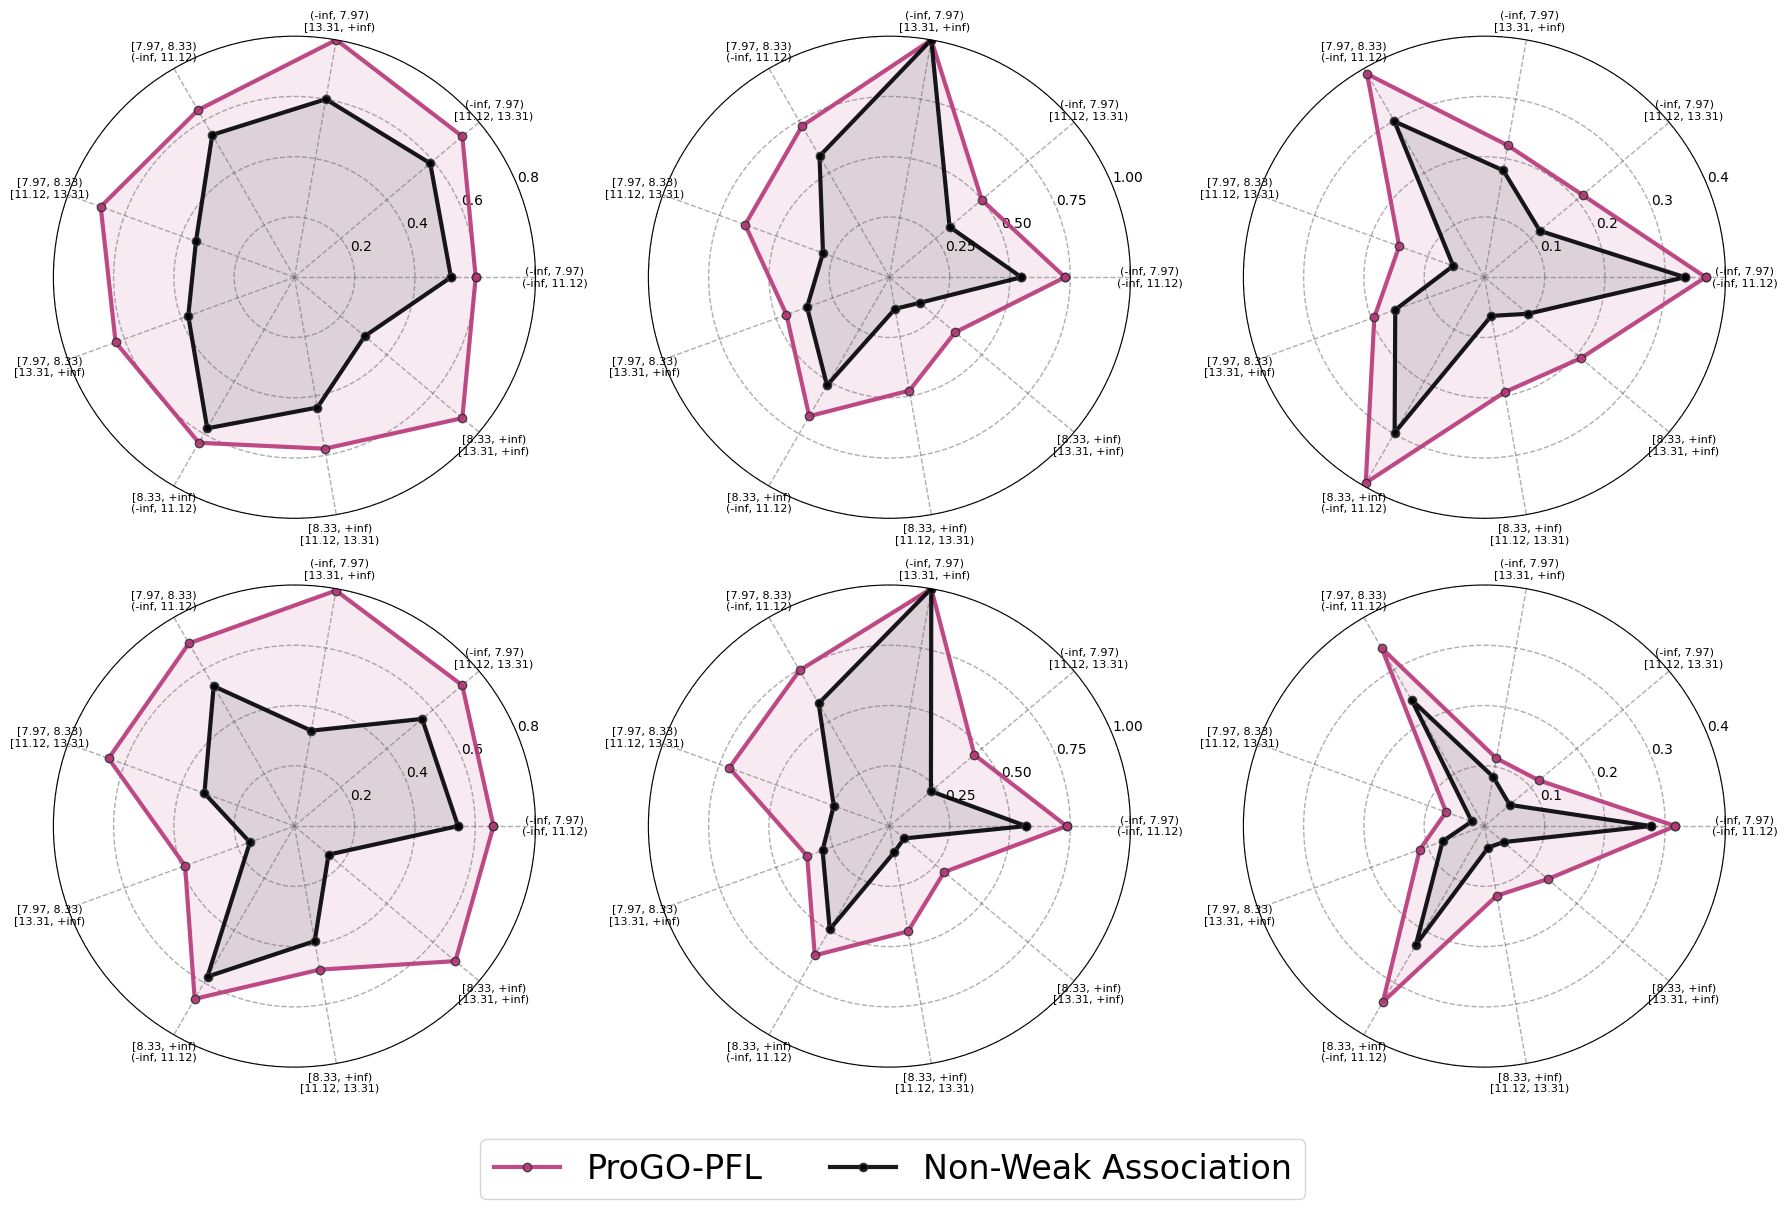

In [78]:
save_dir = prj_root / "notebooks" / "inductive_learning" / "figures"
save_path = save_dir / "multi_level_perf.svg"
# save_path = None
create_radar_plots(perf_df,save_path)

In [48]:
# def create_radar_plots(df):
#     # Filter out rows where both fmax and auprc are NaN or None
#     df_filtered = df.dropna(subset=['fmax', 'auprc'], how='all')
    
#     # Get unique values
#     ontologies = df_filtered['ontology'].unique()
#     methods = df_filtered['method'].unique()
#     metrics = ['fmax', 'auprc']
    
#     # Create a figure with 2 rows and 3 columns
#     fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(projection='polar'))
#     fig.suptitle('Performance Comparison Across Methods and Ontologies', fontsize=16, y=0.95)
    
#     # Color palette for different methods
#     colors = plt.cm.Set3(np.linspace(0, 1, len(methods)))
#     method_colors = dict(zip(methods, colors))
    
#     for row, metric in enumerate(metrics):
#         for col, ontology in enumerate(ontologies):
#             ax = axes[row, col]
            
#             # Filter data for current metric and ontology
#             current_data = df_filtered[df_filtered['ontology'] == ontology]
            
#             if current_data.empty:
#                 ax.set_title(f'{metric.upper()} - {ontology.replace("_", " ").title()}')
#                 continue
            
#             # Group by method and calculate mean values for each protein_ic and go_ic combination
#             # Create categories based on protein_ic and go_ic for radar axes
#             # current_data['category'] = current_data['protein_ic'].astype(str) + ' | ' + current_data['go_ic'].astype(str)
#             current_data = current_data.copy()
#             current_data['category'] = current_data['protein_ic'].astype(str) + ' | ' + current_data['go_ic'].astype(str)

#             categories = sorted(current_data['category'].unique())
            
#             if len(categories) < 3:  # Need at least 3 categories for a meaningful radar plot
#                 ax.text(0.5, 0.5, 'Insufficient\ndata points', ha='center', va='center', transform=ax.transAxes)
#                 ax.set_title(f'{metric.upper()} - {ontology.replace("_", " ").title()}')
#                 continue
            
#             # Calculate angles for each category
#             angles = [n / len(categories) * 2 * pi for n in range(len(categories))]
#             angles += angles[:1]  # Complete the circle
            
#             # Plot each method
#             for method in methods:
#                 method_data = current_data[current_data['method'] == method]
#                 if method_data.empty:
#                     continue
                
#                 values = []
#                 for category in categories:
#                     cat_data = method_data[method_data['category'] == category]
#                     if not cat_data.empty:
#                         # Use mean if multiple values exist for the same category
#                         values.append(cat_data[metric].mean())
#                     else:
#                         values.append(0)  # or np.nan if you prefer
                
#                 values += values[:1]  # Complete the circle
                
#                 # Plot the radar chart
#                 ax.plot(angles, values, 'o-', linewidth=2, label=method, 
#                        color=method_colors[method], alpha=0.7)
#                 ax.fill(angles, values, alpha=0.1, color=method_colors[method])
            
#             # Customize the plot
#             ax.set_xticks(angles[:-1])
#             ax.set_xticklabels([cat.replace(' | ', '\n') for cat in categories], fontsize=8)
#             ax.set_title(f'{metric.upper()} - {ontology.replace("_", " ").title()}', 
#                         fontsize=12, pad=20)
#             ax.grid(True, alpha=0.3)
            
#             # Set y-axis limits based on the metric
#             if metric == 'fmax':
#                 ax.set_ylim(0, 1)
#             elif metric == 'auprc':
#                 ax.set_ylim(0, 1)
    
#     # Add a single legend for all subplots
#     handles, labels = axes[0, 0].get_legend_handles_labels()
#     if handles:  # Only add legend if there are handles
#         fig.legend(handles, labels, loc='center', bbox_to_anchor=(0.5, 0.02), 
#                   ncol=len(methods), fontsize=10)
    
#     plt.tight_layout()
#     plt.subplots_adjust(bottom=0.1)
#     plt.show()
